In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [10]:
try:
  res= pd.read_csv('drive/MyDrive/insurance.csv')
except FileNotFoundError:
  print("file  not found")

In [11]:
res.shape

(1338, 7)

In [12]:
res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [15]:
res.isnull().sum()/res.shape[0]*100 #missing value in percentage

,0
age,0.0
sex,0.0
bmi,0.0
children,0.0
smoker,0.0
region,0.0
expenses,0.0


In [16]:
res.duplicated().sum()

1

In [17]:
res = res.drop_duplicates()

In [20]:
for i in res.select_dtypes(include="object").columns:
  print(i)
  print(res[i].unique())
  print(res[i].value_counts())

sex
['female' 'male']
sex
male      675
female    662
Name: count, dtype: int64
smoker
['yes' 'no']
smoker
no     1063
yes     274
Name: count, dtype: int64
region
['southwest' 'southeast' 'northwest' 'northeast']
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [21]:
res.describe()

,age,bmi,children,expenses
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.665520,1.095737,13279.121638
std,14.044333,6.100664,1.205571,12110.359657
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4746.340000
50%,39.000000,30.400000,1.000000,9386.160000
75%,51.000000,34.700000,2.000000,16657.720000
max,64.000000,53.100000,5.000000,63770.430000


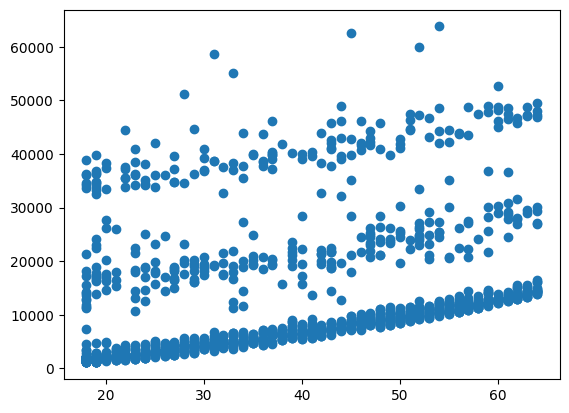

In [22]:
plt.scatter(res['age'],res['expenses'])
plt.show()

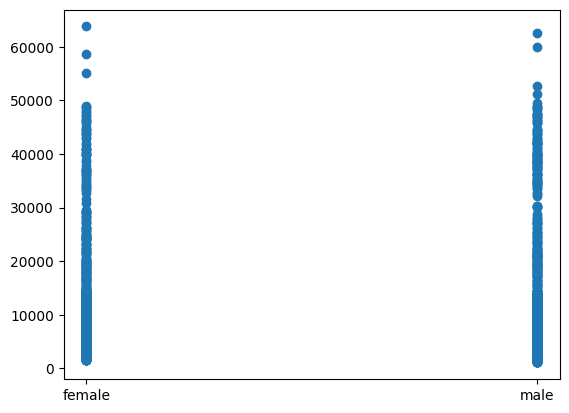

In [23]:
plt.scatter(res['sex'],res['expenses'])
plt.show()

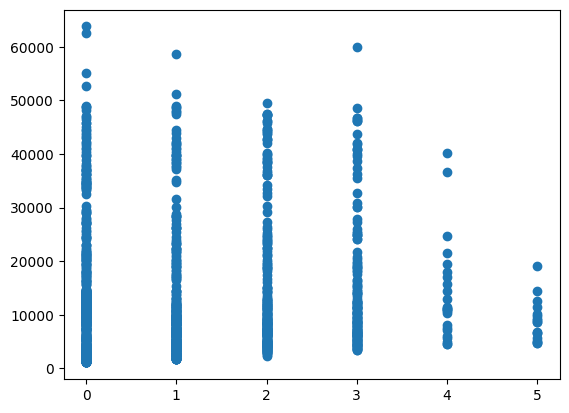

In [26]:
plt.scatter(res['children'],res['expenses'])
plt.show()

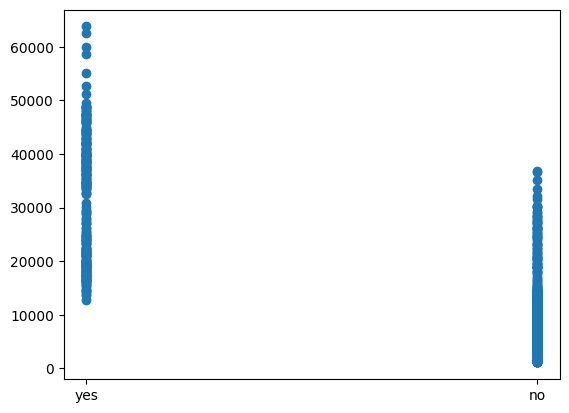

In [24]:
plt.scatter(res['smoker'],res['expenses'])
plt.show()

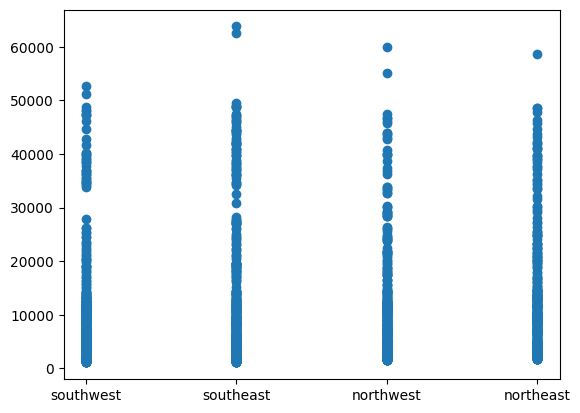

In [25]:
plt.scatter(res['region'],res['expenses'])
plt.show()

In [29]:
X= res[['bmi','age','sex','smoker','children','region']]
y= res['expenses']

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=1200)
len(X_train)

1270

In [51]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # sparse=False for dense output

# Fit the encoder to the categorical features and transform them
encoded_features = encoder.fit_transform(X_train[['sex', 'smoker', 'region']])

# Get feature names from the encoder
encoded_feature_names = encoder.get_feature_names_out(['sex', 'smoker', 'region'])

# Create a DataFrame with the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=X_train.index)

# Concatenate the encoded features with the numerical features
X_train_encoded = pd.concat([X_train[['bmi', 'age', 'children']], encoded_df], axis=1)


In [52]:
from sklearn.linear_model import LinearRegression
clf= LinearRegression()
clf.fit(X_train_encoded,y_train)


LinearRegression()

In [53]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # sparse=False for dense output

# Fit the encoder to the categorical features and transform them
encoded_features_test = encoder.fit_transform(X_test[['sex', 'smoker', 'region']])

# Get feature names from the encoder
encoded_feature_names_test = encoder.get_feature_names_out(['sex', 'smoker', 'region'])

# Create a DataFrame with the encoded features
encoded_df_test = pd.DataFrame(encoded_features_test, columns=encoded_feature_names_test, index=X_test.index)

# Concatenate the encoded features with the numerical features
X_test_encoded = pd.concat([X_test[['bmi', 'age', 'children']], encoded_df_test], axis=1)


In [54]:
len(X_test_encoded)

67

In [71]:
y_predict=clf.predict(X_test_encoded)

In [72]:
clf.score(X_test_encoded,y_test)

0.7896928118191956

In [73]:
clf.intercept_

-730.6716433099209

In [74]:
clf.coef_

array([   339.31442448,    257.48761014,    477.66113579,     27.80174167,
          -27.80174167, -11851.86117063,  11851.86117063,    582.06129016,
          248.09434571,   -376.8319839 ,   -453.32365197])

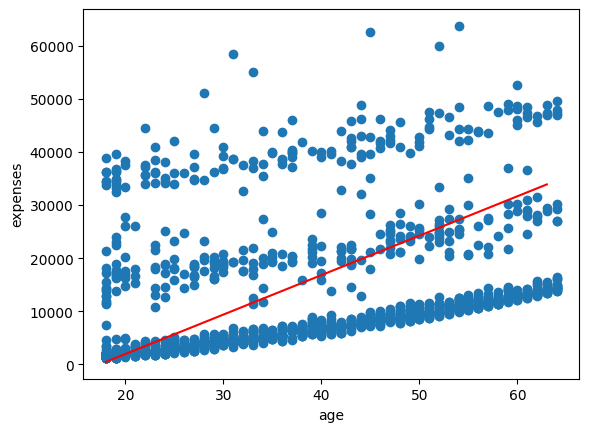

In [80]:
plt.xlabel('age')
plt.ylabel('expenses')
plt.scatter(res['age'],res['expenses'])

y_graph=[y_predict[np.argmin(y_predict)],y_predict[np.argmax(y_predict)]]
x_graph=[res['age'].iloc[np.argmin(y_predict)],res['age'].iloc[np.argmax(y_predict)]]
plt.plot(x_graph,y_graph,color="red")
plt.show()